In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.sin(2 * np.pi * 0.05 * np.arange(100))  # Input signal

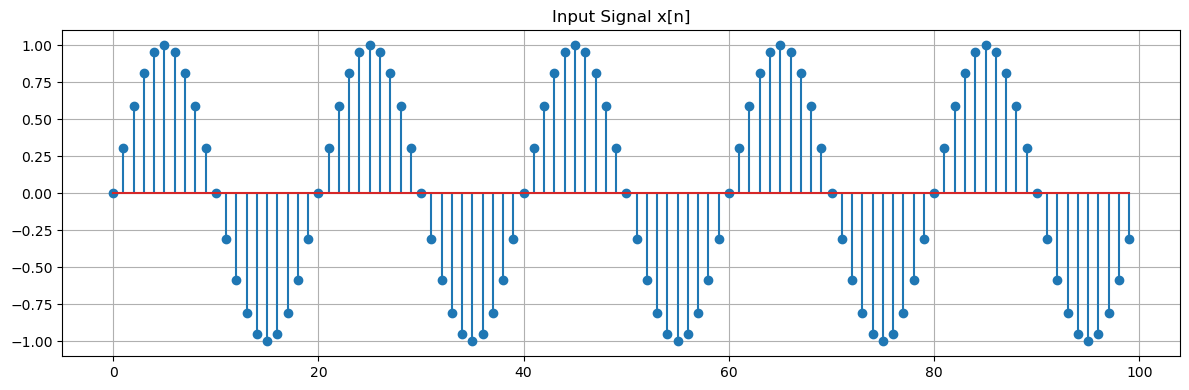

In [3]:
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(x)), x)
plt.title('Input Signal x[n]')  
plt.grid()
plt.tight_layout()
plt.show()

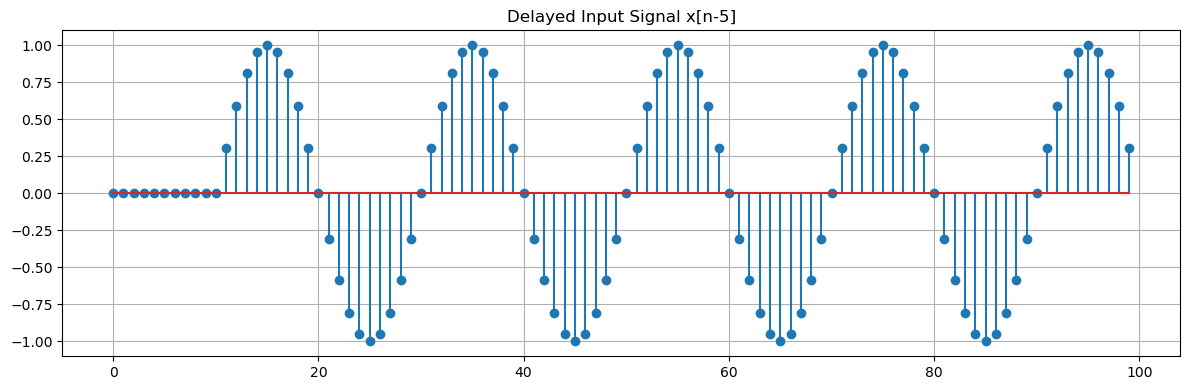

In [5]:
#delay x by 5 samples
x_delayed = np.concatenate((np.zeros(10), x[:-10]))
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(x_delayed)), x_delayed)
plt.title('Delayed Input Signal x[n-5]')
plt.grid()
plt.tight_layout()
plt.show()


In [6]:
#compute cross correlation between x and x_delayed
def manual_convolution(signal, kernel):
    signal_length = len(signal)
    kernel_length = len(kernel)
    output_length = signal_length + kernel_length - 1
    output = np.zeros(output_length)

    for n in range(output_length):
        for k in range(kernel_length):
            if n - k >= 0 and n - k < signal_length:
                output[n] += signal[n - k] * kernel[k]
    
    return output

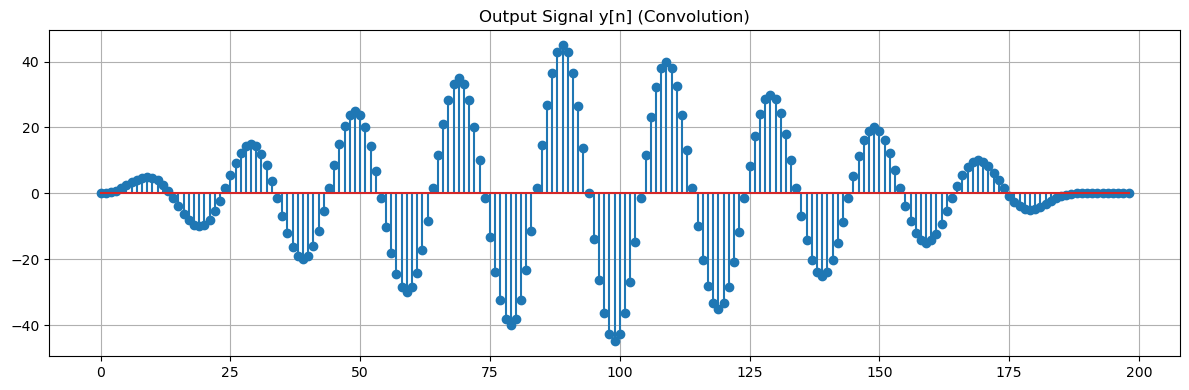

In [8]:
#compute cross correlation between x and x_delayed

h = x_delayed
y = manual_convolution(x, h[::-1])  # Reverse h for correlation
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(y)), y)
plt.title('Output Signal y[n] (Convolution)')
plt.grid()
plt.tight_layout()
plt.show()

In [9]:
#identify the peak in the correlation output
peak_index = np.argmax(y)
print(f'Peak correlation at index: {peak_index}, value: {y[peak_index]}')


Peak correlation at index: 89, value: 45.0
